# 03 — Baseline de Episódios com Janela de 8 Horas

## Objetivo

Construir a primeira base auditada de treinamento e um modelo baseline para responder:

> **Com base nos episódios de alarme iniciados nas 8 horas anteriores, qual é a probabilidade de
> começar ao menos um novo episódio marcado como `Is_Dont_Go` nas próximas 8 horas?**

## Limites da interpretação

- `Is_Dont_Go` indica que o alarme consta na lista entregue; não comprova falha ou parada.
- Este modelo prevê novos episódios da flag fornecida, não falhas operacionais confirmadas.
- A telemetria é um log de eventos. Uma janela sem registros significa apenas “nenhum evento
  registrado”; não prova que o equipamento esteve monitorado e operando normalmente.
- Resultados deste notebook são baseline técnico e não autorizam cálculo de downtime ou ROI.

## Decisões aprovadas

1. preservar integralmente a camada bruta;
2. remover duplicatas exatas apenas da camada analítica, mantendo contagem e rastreabilidade;
3. excluir do treinamento somente o loop localizado da `PE3798`, em 29/06/2025, para os dois
   `Id_Alarme` Remote PTO identificados;
4. formar uma nova sequência quando o mesmo `TAG + Id_Alarme` permanecer mais de 60 segundos sem
   registro;
5. usar 8 horas de observação e 8 horas de horizonte;
6. invalidar amostras cuja observação ou horizonte atravesse a lacuna global de 31/05/2025;
7. separar treino, validação e teste cronologicamente;
8. ajustar vocabulário de alarmes, modelo e threshold sem consultar o teste.

In [1]:
from pathlib import Path
import json
import time

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, confusion_matrix,
    f1_score, fbeta_score, precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 150)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

SEQUENCE_GAP_SECONDS = 60
OBSERVATION_HOURS = 8
HORIZON_HOURS = 8
TOP_ALARM_IDS = 200
MISSING_DAY = pd.Timestamp("2025-05-31")
LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

print(f"Raiz do projeto: {ROOT}")
print(f"Gap de sequência: {SEQUENCE_GAP_SECONDS}s")
print(f"Observação/horizonte: {OBSERVATION_HOURS}h/{HORIZON_HOURS}h")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Gap de sequência: 60s
Observação/horizonte: 8h/8h


## 1. Controle da limpeza analítica

### Duplicatas

`Id_Eventos_Telemetria` identifica o registro individual, `TAG` identifica o equipamento e
`Id_Alarme` identifica o tipo de alarme. Duas linhas com IDs de evento diferentes, mas igualdade em
todas as demais colunas, são tratadas como cópias exatas na camada analítica.

### Loop localizado

Somente a seguinte combinação é retirada da camada de treinamento:

```text
TAG = PE3798
data = 2025-06-29
Id_Alarme IN (1241582851, 1241582848)
```

Os demais registros da PE3798, do mesmo dia e desses alarmes em outros períodos são preservados.

In [2]:
audit_before = query(
    f'''
    SELECT
        count(*) AS registros_brutos,
        count(DISTINCT Id_Eventos_Telemetria) AS ids_evento_distintos,
        count(*) FILTER (
            WHERE TAG = '{LOOP_TAG}'
              AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
              AND Id_Alarme IN {LOOP_ALARM_IDS}
        ) AS registros_loop_localizado,
        count(*) FILTER (
            WHERE CAST(Data_Evento AS DATE) = DATE '{MISSING_DAY.date()}'
        ) AS registros_dia_ausente
    FROM tel
    '''
)
display(audit_before)

loop_detail = query(
    f'''
    SELECT Id_Alarme, Alarme, count(*) AS registros,
           count(DISTINCT Data_Evento) AS timestamps,
           sum(Is_Dont_Go) AS dont_go,
           min(Data_Evento) AS inicio, max(Data_Evento) AS fim
    FROM tel
    WHERE TAG = '{LOOP_TAG}'
      AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
      AND Id_Alarme IN {LOOP_ALARM_IDS}
    GROUP BY 1, 2 ORDER BY registros DESC
    '''
)
display(loop_detail)

,registros_brutos,ids_evento_distintos,registros_loop_localizado,registros_dia_ausente
0,37164054,37164054,1290396,0


,Id_Alarme,Alarme,registros,timestamps,dont_go,inicio,fim
0,1241582851,Remote PTO Preprogrammed Speed Control Switch ...,645199,645199,0.0,2025-06-29 00:28:35.143,2025-06-29 19:14:17.070
1,1241582848,Remote PTO Preprogrammed Speed Control Switch ...,645197,645197,0.0,2025-06-29 00:28:35.393,2025-06-29 19:14:17.017


## 2. Camada analítica deduplicada

O agrupamento considera todas as colunas originais, exceto o identificador único do evento. O menor
ID é mantido como referência e `ids_evento_no_grupo` registra quantas linhas brutas foram
representadas.

Essa operação não altera os arquivos brutos.

In [3]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

audit_cleaning = query(
    '''
    SELECT
        sum(ids_evento_no_grupo) AS registros_apos_loop_antes_dedup,
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo - 1) AS duplicatas_exatas_retiradas,
        count(*) FILTER (WHERE ids_evento_no_grupo > 1) AS grupos_com_duplicata,
        sum(Is_Dont_Go) AS linhas_dont_go_analiticas
    FROM analytic_events
    '''
)
audit_cleaning["tempo_processamento_s"] = round(time.time() - start, 1)
display(audit_cleaning)

assert audit_before.loc[0, "registros_brutos"] == (
    audit_cleaning.loc[0, "registros_apos_loop_antes_dedup"]
    + audit_before.loc[0, "registros_loop_localizado"]
)

,registros_apos_loop_antes_dedup,registros_analiticos,duplicatas_exatas_retiradas,grupos_com_duplicata,linhas_dont_go_analiticas,tempo_processamento_s
0,35873658.0,35608094,265564.0,265556,19941.0,15.7


## 3. Formação das sequências de alarme

Para cada `TAG + Id_Alarme`, um registro inicia nova sequência quando:

- é o primeiro registro da combinação; ou
- ocorreu mais de 60 segundos após o registro anterior.

O limite de 60 segundos é um parâmetro inicial aprovado para o baseline. Não afirmamos que ele seja
o limite operacional definitivo.

Uma sequência é considerada `Dont Go` quando ao menos uma linha que a compõe possui
`Is_Dont_Go = 1`. O target utiliza o **início da sequência**, evitando contar sua continuidade na
janela seguinte como uma nova ocorrência.

In [4]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE alarm_sequences AS
    WITH ordered AS (
        SELECT *,
               lag(Data_Evento) OVER (
                   PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
               ) AS evento_anterior
        FROM analytic_events
    ), flagged AS (
        SELECT *,
               CASE
                   WHEN evento_anterior IS NULL THEN 1
                   WHEN date_diff('millisecond', evento_anterior, Data_Evento)
                        > {SEQUENCE_GAP_SECONDS * 1000} THEN 1
                   ELSE 0
               END AS nova_sequencia
        FROM ordered
    ), numbered AS (
        SELECT *,
               sum(nova_sequencia) OVER (
                   PARTITION BY TAG, Id_Alarme
                   ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
               ) AS numero_sequencia
        FROM flagged
    )
    SELECT
        TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
        Id_Alarme, any_value(Alarme) AS Alarme,
        numero_sequencia,
        min(Data_Evento) AS inicio,
        max(Data_Evento) AS fim,
        date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo) AS registros_brutos_representados,
        max(Is_Dont_Go) AS is_dont_go,
        max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
        max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
        max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
        max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
    FROM numbered
    GROUP BY TAG, Id_Alarme, numero_sequencia
    '''
)

sequence_audit = query(
    '''
    SELECT
        count(*) AS sequencias,
        sum(is_dont_go) AS sequencias_dont_go,
        count(DISTINCT TAG) AS tags,
        count(DISTINCT Id_Alarme) AS ids_alarme,
        median(duracao_ms) AS mediana_duracao_ms,
        quantile_cont(duracao_ms, .90) AS p90_duracao_ms,
        max(registros_analiticos) AS maior_sequencia_registros
    FROM alarm_sequences
    '''
)
sequence_audit["tempo_processamento_s"] = round(time.time() - start, 1)
display(sequence_audit)

positive_class_audit = query(
    '''
    SELECT possui_activate, possui_inactive, possui_classe_nula,
           count(*) AS sequencias_dont_go
    FROM alarm_sequences
    WHERE is_dont_go = 1
    GROUP BY ALL ORDER BY sequencias_dont_go DESC
    '''
)
display(positive_class_audit)

id_target_behavior = query(
    '''
    WITH behavior AS (
        SELECT Id_Alarme, min(Is_Dont_Go) AS minimo, max(Is_Dont_Go) AS maximo,
               count(*) AS registros
        FROM analytic_events
        GROUP BY 1
    )
    SELECT
        CASE
            WHEN minimo = 0 AND maximo = 0 THEN 'sempre_0'
            WHEN minimo = 1 AND maximo = 1 THEN 'sempre_1'
            ELSE 'misto'
        END AS comportamento,
        count(*) AS ids_alarme,
        sum(registros) AS registros
    FROM behavior
    GROUP BY 1 ORDER BY 1
    '''
)
display(id_target_behavior)

,sequencias,sequencias_dont_go,tags,ids_alarme,mediana_duracao_ms,p90_duracao_ms,maior_sequencia_registros,tempo_processamento_s
0,4303625,14612.0,35,1324,0.0,203950.0,20604,77.1


,possui_activate,possui_inactive,possui_classe_nula,sequencias_dont_go
0,1,0,0,14445
1,0,0,0,167


,comportamento,ids_alarme,registros
0,misto,27,115515.0
1,sempre_0,1277,35489889.0
2,sempre_1,20,2690.0


## 4. Janelas calendarizadas e lacuna de 31/05

As fronteiras são fixas em `00:00`, `08:00` e `16:00`. Para uma previsão no instante `t`:

- features: sequências iniciadas em `[t-8h, t)`;
- target: sequências `Dont Go` iniciadas em `[t, t+8h)`.

Não preenchemos 31/05 com zeros. Amostras são invalidadas quando a janela de observação ou o
horizonte coincide com qualquer parte desse dia. Assim, nenhuma amostra conecta 30/05 a 01/06.

In [5]:
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sequence_bins AS
    SELECT
        TAG,
        time_bucket(INTERVAL '8 hours', inicio) AS bin_start,
        count(*) AS sequencias_total,
        count(DISTINCT Id_Alarme) AS alarmes_distintos,
        sum(registros_analiticos) AS registros_analiticos,
        sum(registros_brutos_representados) AS registros_brutos_representados,
        avg(duracao_ms) AS duracao_media_ms,
        max(duracao_ms) AS duracao_max_ms,
        max(registros_analiticos) AS maior_sequencia_registros,
        sum(possui_critico) AS sequencias_com_critico,
        sum(possui_activate) AS sequencias_com_activate,
        sum(possui_inactive) AS sequencias_com_inactive,
        sum(possui_classe_nula) AS sequencias_com_classe_nula,
        sum(is_dont_go) AS episodios_dont_go
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)

con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sample_grid AS
    WITH tags AS (
        SELECT DISTINCT TAG FROM analytic_events
    ), feature_bins AS (
        SELECT * FROM generate_series(
            TIMESTAMP '2025-01-01 00:00:00',
            TIMESTAMP '2025-06-30 08:00:00',
            INTERVAL '8 hours'
        ) AS t(feature_start)
    )
    SELECT
        tags.TAG,
        feature_start,
        feature_start + INTERVAL '8 hours' AS prediction_time,
        feature_start + INTERVAL '16 hours' AS target_end
    FROM tags CROSS JOIN feature_bins
    '''
)

samples = query(
    f'''
    SELECT
        g.TAG, g.feature_start, g.prediction_time, g.target_end,
        coalesce(f.sequencias_total, 0) AS sequencias_total,
        coalesce(f.alarmes_distintos, 0) AS alarmes_distintos,
        coalesce(f.registros_analiticos, 0) AS registros_analiticos,
        coalesce(f.registros_brutos_representados, 0) AS registros_brutos_representados,
        coalesce(f.duracao_media_ms, 0) AS duracao_media_ms,
        coalesce(f.duracao_max_ms, 0) AS duracao_max_ms,
        coalesce(f.maior_sequencia_registros, 0) AS maior_sequencia_registros,
        coalesce(f.sequencias_com_critico, 0) AS sequencias_com_critico,
        coalesce(f.sequencias_com_activate, 0) AS sequencias_com_activate,
        coalesce(f.sequencias_com_inactive, 0) AS sequencias_com_inactive,
        coalesce(f.sequencias_com_classe_nula, 0) AS sequencias_com_classe_nula,
        coalesce(y.episodios_dont_go, 0) AS episodios_dont_go_target,
        CASE WHEN coalesce(y.episodios_dont_go, 0) > 0 THEN 1 ELSE 0 END AS target,
        CASE
            WHEN CAST(g.feature_start AS DATE) = DATE '{MISSING_DAY.date()}'
              OR CAST(g.prediction_time AS DATE) = DATE '{MISSING_DAY.date()}'
            THEN 0 ELSE 1
        END AS amostra_valida
    FROM sample_grid g
    LEFT JOIN sequence_bins f
      ON g.TAG = f.TAG AND g.feature_start = f.bin_start
    LEFT JOIN sequence_bins y
      ON g.TAG = y.TAG AND g.prediction_time = y.bin_start
    ORDER BY g.prediction_time, g.TAG
    '''
)

invalid_gap = samples[samples["amostra_valida"] == 0]
print(f"Amostras invalidadas pela lacuna: {len(invalid_gap):,}")
display(invalid_gap.groupby(invalid_gap["prediction_time"].dt.floor("D")).size().reset_index(name="amostras"))

samples = samples[samples["amostra_valida"] == 1].copy()

Amostras invalidadas pela lacuna: 140


,prediction_time,amostras
0,2025-05-31,105
1,2025-06-01,35


## 5. Vocabulário de alarmes sem vazamento

Para manter o baseline interpretável e computacionalmente controlado, usamos os 200 `Id_Alarme`
com mais sequências **somente no período de treino**. A seleção não consulta o target, a validação ou
o teste.

Sequências de outros IDs permanecem representadas nas variáveis agregadas gerais.

In [6]:
top_alarm_ids = query(
    f'''
    SELECT Id_Alarme, count(*) AS sequencias
    FROM alarm_sequences
    WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
    GROUP BY 1
    ORDER BY sequencias DESC, Id_Alarme
    LIMIT {TOP_ALARM_IDS}
    '''
)
alarm_ids = top_alarm_ids["Id_Alarme"].astype(int).tolist()
print(f"IDs selecionados exclusivamente no treino: {len(alarm_ids)}")
display(top_alarm_ids.head(20))

alarm_columns = ",\n".join(
    f"sum(CASE WHEN Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
    for alarm_id in alarm_ids
)
alarm_bin_features = query(
    f'''
    SELECT TAG, time_bucket(INTERVAL '8 hours', inicio) AS feature_start,
           {alarm_columns}
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)

samples = samples.merge(alarm_bin_features, how="left", on=["TAG", "feature_start"])
alarm_feature_names = [f"alarm_{alarm_id}" for alarm_id in alarm_ids]
samples[alarm_feature_names] = samples[alarm_feature_names].fillna(0).astype("int32")

derived_features = pd.DataFrame({
    "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
    "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
    "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
    "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
    "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
}, index=samples.index)
samples = pd.concat([samples, derived_features], axis=1).copy()

IDs selecionados exclusivamente no treino: 200


,Id_Alarme,sequencias
0,335609934,182752
1,335609935,182624
2,1074008262,111374
3,1074008247,105921
4,1074008259,101078
5,1074008258,96490
6,1074008261,85451
7,1074008264,84072
8,335609927,81822
9,1074008257,80897


## 6. Split temporal e auditoria de vazamento

- **Treino:** janeiro a abril de 2025;
- **Validação:** 1 a 30 de maio de 2025;
- **Teste:** junho de 2025, após o embargo causado pela lacuna de 31/05.

O teste não participa da escolha de features, hiperparâmetros ou threshold. Não usamos split
aleatório porque janelas próximas compartilham regime operacional, equipamentos e recorrência de
alarmes; embaralhá-las produziria validação otimista.

In [7]:
samples = samples.assign(split=np.select(
    [
        samples["prediction_time"] < pd.Timestamp("2025-05-01"),
        samples["prediction_time"] < pd.Timestamp("2025-05-31"),
        samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
    ],
    ["treino", "validacao", "teste"],
    default="fora_do_split",
))
samples = samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()

base_feature_columns = [
    "sequencias_total", "alarmes_distintos", "registros_analiticos",
    "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
    "maior_sequencia_registros", "sequencias_com_critico",
    "sequencias_com_activate", "sequencias_com_inactive",
    "sequencias_com_classe_nula", "feature_has_events",
    "prediction_hour_sin", "prediction_hour_cos",
    "prediction_dow_sin", "prediction_dow_cos",
]
feature_columns = base_feature_columns + alarm_feature_names

for forbidden in ["target", "dont_go", "dontgo", "episodios_dont_go_target"]:
    assert not any(forbidden in col.casefold() for col in feature_columns)

split_audit = (
    samples.groupby("split")
    .agg(
        amostras=("target", "size"),
        positivas=("target", "sum"),
        prevalencia=("target", "mean"),
        inicio=("prediction_time", "min"),
        fim=("prediction_time", "max"),
        tags=("TAG", "nunique"),
        janelas_sem_eventos=("feature_has_events", lambda x: (x == 0).sum()),
    )
    .reset_index()
)
display(split_audit)

assert samples.loc[samples["split"] == "treino", "prediction_time"].max() < samples.loc[samples["split"] == "validacao", "prediction_time"].min()
assert samples.loc[samples["split"] == "validacao", "prediction_time"].max() < samples.loc[samples["split"] == "teste", "prediction_time"].min()
assert not ((samples["feature_start"].dt.date == MISSING_DAY.date()) | (samples["prediction_time"].dt.date == MISSING_DAY.date())).any()

,split,amostras,positivas,prevalencia,inicio,fim,tags,janelas_sem_eventos
0,teste,3115,290,0.093098,2025-06-01 08:00:00,2025-06-30 16:00:00,35,731
1,treino,12565,1922,0.152965,2025-01-01 08:00:00,2025-04-30 16:00:00,35,2913
2,validacao,3150,288,0.091429,2025-05-01 00:00:00,2025-05-30 16:00:00,35,758


## 7. Baselines

O `DummyClassifier` é apenas um controle de sanidade. Treinamos duas versões do
`RandomForestClassifier`, ambas com pesos balanceados e sem busca de hiperparâmetros:

- **agregado:** somente métricas gerais das sequências;
- **com IDs:** métricas gerais mais contagens dos 200 IDs selecionados no treino.

Essa comparação mede quanto do desempenho vem da dinâmica geral e quanto depende da recorrência de
tipos específicos de alarme.

O threshold é selecionado **na validação**, maximizando F2 para atribuir mais peso ao recall. Essa
escolha é provisória: ainda não existe custo operacional validado para falsos positivos e falsos
negativos.

Accuracy não é usada como métrica principal devido ao forte desbalanceamento. Priorizamos:

- PR-AUC;
- recall e precisão;
- F2 e F1;
- balanced accuracy;
- matriz de confusão.

,modelo,threshold,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas
0,Dummy_prior,0.500,0.091429,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0
1,RandomForest_agregado,0.155,0.221254,0.737336,0.163075,0.788194,0.270238,0.446148,0.690568,1392
2,RandomForest_com_IDs,0.205,0.335803,0.788176,0.203685,0.690972,0.314625,0.467356,0.709567,977


Threshold agregado: 0.155
Threshold com IDs: 0.205


,feature,importance
9,sequencias_com_inactive,0.055885
8,sequencias_com_activate,0.052854
52,alarm_84608752,0.051197
51,alarm_84608753,0.049854
1,alarmes_distintos,0.038382
3,registros_brutos_representados,0.035991
2,registros_analiticos,0.035836
0,sequencias_total,0.034556
5,duracao_max_ms,0.034183
4,duracao_media_ms,0.032102


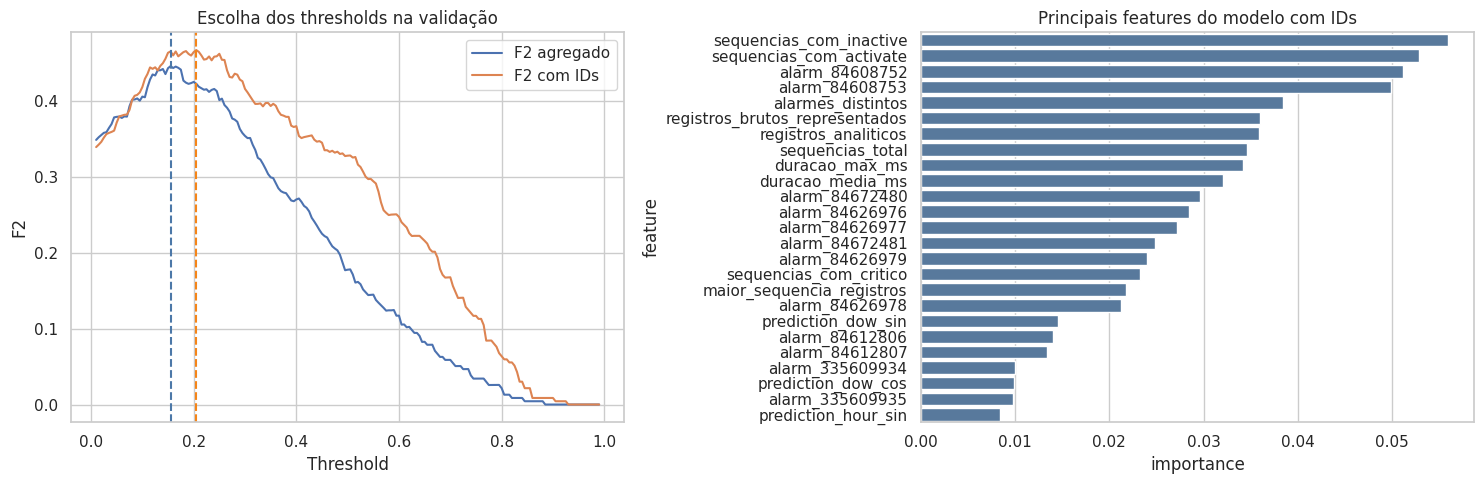

In [8]:
def get_split(name, columns):
    part = samples[samples["split"] == name]
    return part[columns].astype("float32"), part["target"].astype("int8"), part

X_train_base, y_train, train_meta = get_split("treino", base_feature_columns)
X_val_base, y_val, val_meta = get_split("validacao", base_feature_columns)
X_test_base, y_test, test_meta = get_split("teste", base_feature_columns)

X_train, _, _ = get_split("treino", feature_columns)
X_val, _, _ = get_split("validacao", feature_columns)
X_test, _, _ = get_split("teste", feature_columns)

def metric_row(name, y_true, probability, threshold):
    prediction = (probability >= threshold).astype(int)
    return {
        "modelo": name,
        "threshold": threshold,
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "f2": fbeta_score(y_true, prediction, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "predicoes_positivas": int(prediction.sum()),
    }

dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train_base, y_train)
dummy_val_prob = dummy.predict_proba(X_val_base)[:, 1]

rf_params = dict(
    n_estimators=400,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

rf_base = RandomForestClassifier(**rf_params)
rf_base.fit(X_train_base, y_train)
rf_base_val_prob = rf_base.predict_proba(X_val_base)[:, 1]

rf_ids = RandomForestClassifier(**rf_params)
rf_ids.fit(X_train, y_train)
rf_ids_val_prob = rf_ids.predict_proba(X_val)[:, 1]

def select_threshold(y_true, probability):
    scores = pd.DataFrame([
        {
            "threshold": threshold,
            "f2": fbeta_score(y_true, probability >= threshold, beta=2, zero_division=0),
            "precision": precision_score(y_true, probability >= threshold, zero_division=0),
            "recall": recall_score(y_true, probability >= threshold, zero_division=0),
        }
        for threshold in np.linspace(0.01, 0.99, 197)
    ])
    best = scores.sort_values(
        ["f2", "precision", "threshold"], ascending=[False, False, False]
    ).iloc[0]["threshold"]
    return float(best), scores

base_threshold, base_threshold_scores = select_threshold(y_val, rf_base_val_prob)
ids_threshold, ids_threshold_scores = select_threshold(y_val, rf_ids_val_prob)

validation_metrics = pd.DataFrame([
    metric_row("Dummy_prior", y_val, dummy_val_prob, 0.5),
    metric_row("RandomForest_agregado", y_val, rf_base_val_prob, base_threshold),
    metric_row("RandomForest_com_IDs", y_val, rf_ids_val_prob, ids_threshold),
])
display(validation_metrics)
print(f"Threshold agregado: {base_threshold:.3f}")
print(f"Threshold com IDs: {ids_threshold:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(base_threshold_scores["threshold"], base_threshold_scores["f2"], label="F2 agregado")
axes[0].plot(ids_threshold_scores["threshold"], ids_threshold_scores["f2"], label="F2 com IDs")
axes[0].axvline(base_threshold, color="#4C78A8", linestyle="--")
axes[0].axvline(ids_threshold, color="#F58518", linestyle="--")
axes[0].set(title="Escolha dos thresholds na validação", xlabel="Threshold", ylabel="F2")
axes[0].legend()

importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_ids.feature_importances_,
}).sort_values("importance", ascending=False).head(25)
display(importance)
sns.barplot(data=importance, x="importance", y="feature", ax=axes[1], color="#4C78A8")
axes[1].set(title="Principais features do modelo com IDs")
plt.tight_layout()
plt.show()

## 8. Avaliação final no teste

O conjunto de junho é consultado uma única vez usando o modelo treinado em janeiro–abril e o
threshold escolhido em maio. Não há retreino após observar a validação, para manter esta primeira
comparação totalmente rastreável.

,modelo,threshold,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas
0,Dummy_prior,0.500,0.093098,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0
1,RandomForest_agregado,0.155,0.210773,0.750813,0.166199,0.817241,0.276224,0.458237,0.698178,1426
2,RandomForest_com_IDs,0.205,0.330037,0.807777,0.210019,0.751724,0.328313,0.495905,0.730729,1038


,Previsto 0,Previsto 1
Real 0,2005,820
Real 1,72,218


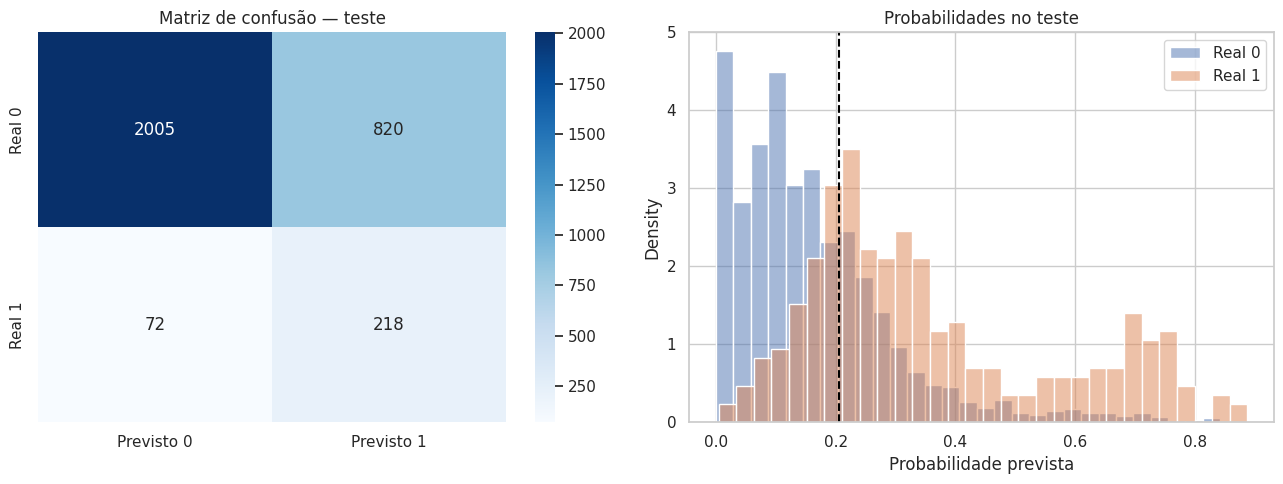

In [9]:
dummy_test_prob = dummy.predict_proba(X_test_base)[:, 1]
rf_base_test_prob = rf_base.predict_proba(X_test_base)[:, 1]
rf_ids_test_prob = rf_ids.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame([
    metric_row("Dummy_prior", y_test, dummy_test_prob, 0.5),
    metric_row("RandomForest_agregado", y_test, rf_base_test_prob, base_threshold),
    metric_row("RandomForest_com_IDs", y_test, rf_ids_test_prob, ids_threshold),
])
display(test_metrics)

rf_test_pred = (rf_ids_test_prob >= ids_threshold).astype(int)
cm = confusion_matrix(y_test, rf_test_pred)
cm_df = pd.DataFrame(cm, index=["Real 0", "Real 1"], columns=["Previsto 0", "Previsto 1"])
display(cm_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set(title="Matriz de confusão — teste")
sns.histplot(rf_ids_test_prob[y_test.to_numpy() == 0], bins=30, stat="density", alpha=.5, label="Real 0", ax=axes[1])
sns.histplot(rf_ids_test_prob[y_test.to_numpy() == 1], bins=30, stat="density", alpha=.5, label="Real 1", ax=axes[1])
axes[1].axvline(ids_threshold, color="black", linestyle="--")
axes[1].set(title="Probabilidades no teste", xlabel="Probabilidade prevista")
axes[1].legend()
plt.tight_layout()
plt.show()

## 9. Checklist de auditoria e próximos experimentos

### O que este baseline permite concluir

- se a limpeza e a formação de sequências produzem uma base temporal treinável;
- se padrões das 8 horas anteriores carregam informação sobre novos episódios nas 8 horas seguintes;
- quais IDs e métricas agregadas dominam a previsão;
- quanto o desempenho muda entre maio e junho.

### O que ele não permite concluir

- que um episódio `Dont Go` seja falha real;
- que 60 segundos ou 8 horas sejam parâmetros ótimos;
- que ausência de eventos represente telemetria saudável;
- que a importância de um `Id_Alarme` seja causal;
- que o modelo esteja pronto para produção.

### Próximos testes, após auditoria deste resultado

1. comparar outros limites de sequência;
2. comparar janelas de observação e horizontes;
3. criar famílias/conceitos de alarme;
4. testar features multijanelas;
5. avaliar estados operacionais nos cinco cenários já definidos;
6. comparar Random Forest com XGBoost mantendo exatamente a mesma base;
7. validar target contra consequência operacional observável.